# Arabic Sentiment Classification with Word and Character Features

Developed an Arabic sentiment-classification pipeline with word and character TF-IDF features, duplicate checks and validation-based model selection. On a held-out set of 5,217 texts, the selected model achieved 70.85% accuracy and 0.709 macro F1, compared with 61.80% accuracy for an RBF-SVM baseline on the same split. Preserved negation and emoji and documented uncertainty in the source labels.

This notebook reviews saved results. The experiment script was executed separately. Enable the optional rerun only after configuring your dataset.

## Method

Applied Arabic normalization while retaining negation and emoji. Removed conflicting duplicate labels and deduplicated normalized text before a stratified 60/20/20 split. Compared five word/character TF-IDF classifiers. Vocabulary and IDF weights are learned from training data only. Validation macro F1 selects the model; development data then trains the final model.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
root = Path.cwd()
metrics = json.loads((root / 'results' / 'metrics.json').read_text(encoding='utf8'))
if 'test_results' in metrics:
    display(pd.DataFrame(metrics['test_results']).T)
else:
    display(pd.DataFrame({'value': {k:v for k,v in metrics.items() if isinstance(v,(str,int,float))}}))

,accuracy,balanced_accuracy,macro_f1,weighted_f1,accuracy_95pct_wilson
RBF-SVM baseline,0.61798,0.617853,0.618275,0.618241,"[0.6047125618878936, 0.6310731780970161]"
Word+character TFIDF + LogisticRegression,0.708453,0.708752,0.708621,0.708267,"[0.69597071241378, 0.7206287875595576]"


## Recorded environment and data provenance

In [2]:
display(metrics.get('environment', {}))
print('Data fingerprint:', metrics.get('input_sha256', metrics.get('audit',{}).get('input_sha256','see dataset checksums')))

{'python': '3.12.2',
 'numpy': '2.5.3',
 'pandas': '3.0.6',
 'sklearn': '1.9.1',
 'scipy': '1.18.1',
 'seed': 42}

Data fingerprint: 4e32752d3c18d7250f2b7e8b6053d333e9d8191a12884730fabac158fd9d5998


## Figures

test_confusion_matrix.png


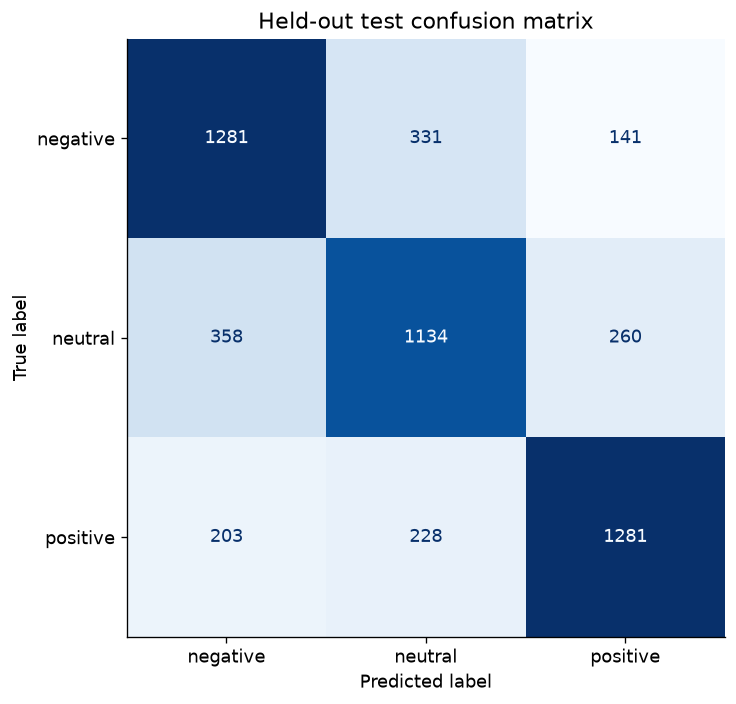

validation_comparison.png


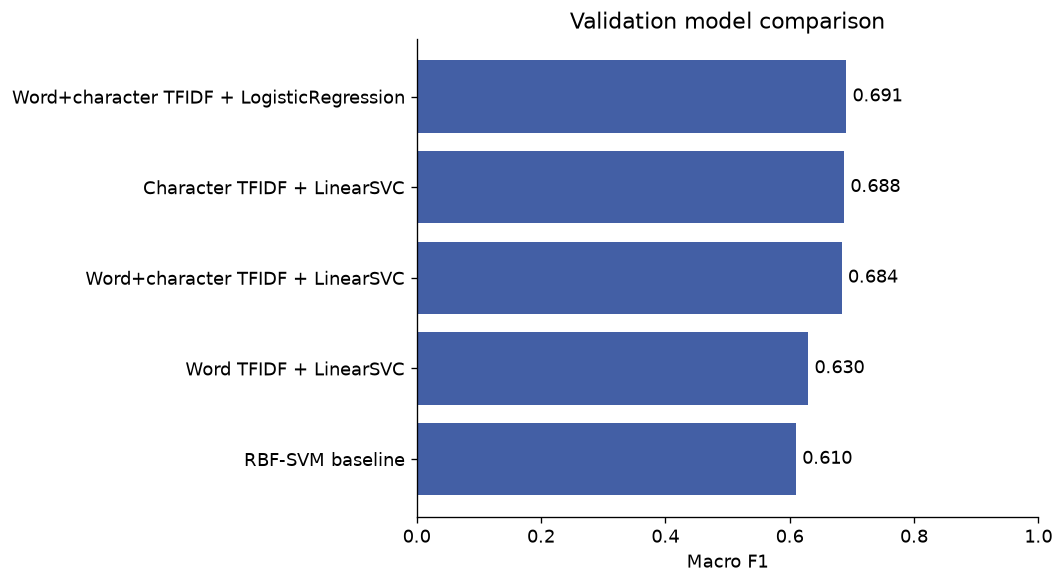

In [3]:
for figure in sorted((root / 'results').glob('*.png')):
    print(figure.name)
    display(Image(filename=str(figure)))

## Interpretation and limitations

This is an internal benchmark on the supplied dataset; its label provenance is unverified. A random split is not proof of generalization to new authors, time periods, domains or dialects. The earlier notebook score used a different split and should not be treated as a controlled comparison.

## Optional full rerun

Adjust the dataset path in the command. This may download files or train a model and can take time. Results below are never produced from synthetic placeholder data.

In [4]:
RERUN_EXPERIMENT = False
if RERUN_EXPERIMENT:
    import subprocess, sys, shlex
    command = 'python train.py --data data/arabic_tweets.xlsx --out results'
    subprocess.run([sys.executable] + shlex.split(command)[1:], cwd=root, check=True)